# 🧠 Neural Network Visualizer
### Draw any digit → watch neurons fire layer by layer in real time

---

| Step | What happens |
|------|--------------|
| 1 | Load MNIST — 60,000 real handwritten digits |
| 2 | Build neural network: 784 → 128 → 64 → 10 |
| 3 | Train it — watch accuracy climb to 97%+ |
| 4 | Export trained weights to JavaScript |
| 5 | **Interactive visualizer** — draw → predict → see neurons fire |

**YouTube: SkillWisor**

## 📦 Step 0: Install & Import

In [1]:
import json, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import display, HTML

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Ready | Device: {device} | PyTorch: {torch.__version__}')

✅ Ready | Device: cpu | PyTorch: 2.10.0+cpu


---
## 📚 Step 1: Load MNIST

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.95MB/s]


✅ MNIST loaded: 60,000 train | 10,000 test
   Each image: 28×28 = 784 pixels → 10 digit classes


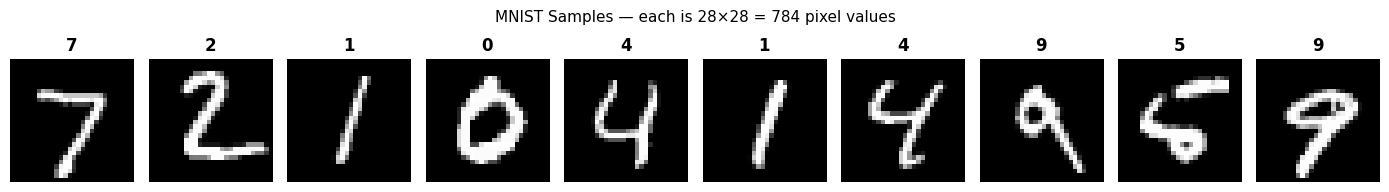

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_ld = DataLoader(train_ds, batch_size=256, shuffle=True)
test_ld  = DataLoader(test_ds,  batch_size=1000)

print(f'✅ MNIST loaded: {len(train_ds):,} train | {len(test_ds):,} test')
print(f'   Each image: 28×28 = 784 pixels → 10 digit classes')

# Show samples
imgs, labs = next(iter(DataLoader(test_ds, batch_size=10, shuffle=False)))
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i,0], cmap='gray')
    ax.set_title(str(labs[i].item()), fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('MNIST Samples — each is 28×28 = 784 pixel values', fontsize=11)
plt.tight_layout()
plt.show()

---
## 🏗️ Step 2: Build the Neural Network

```
Input (784)  →  Hidden1 (128)  →  Hidden2 (64)  →  Output (10)
28×28 pixels    ReLU + BN          ReLU + BN         probabilities
```

In [3]:
class DigitNet(nn.Module):
    """
    3-layer network for MNIST digit classification.
    Architecture: 784 → 128 → 64 → 10

    We export weights after training so JavaScript
    can run the EXACT same forward pass in the browser.
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)
        self.drop = nn.Dropout(0.3)

    def forward(self, x, return_acts=False):
        x = x.view(x.size(0), -1)            # flatten 28×28 → 784
        z1 = self.fc1(x)
        h1 = F.relu(self.bn1(z1))             # hidden layer 1
        h1 = self.drop(h1)
        z2 = self.fc2(h1)
        h2 = F.relu(self.bn2(z2))             # hidden layer 2
        out = self.fc3(h2)                    # output logits
        if return_acts:
            return out, h1, h2
        return out

model = DigitNet().to(device)
total = sum(p.numel() for p in model.parameters())
print(f'✅ DigitNet created')
print(f'   Layer 1: 784 → 128  ({784*128+128:,} params)')
print(f'   Layer 2: 128 → 64   ({128*64+64:,} params)')
print(f'   Layer 3: 64  → 10   ({64*10+10:,} params)')
print(f'   Total: {total:,} parameters')

✅ DigitNet created
   Layer 1: 784 → 128  (100,480 params)
   Layer 2: 128 → 64   (8,256 params)
   Layer 3: 64  → 10   (650 params)
   Total: 109,770 parameters


---
## 🏋️ Step 3: Train on 60,000 Digits

In [4]:
EPOCHS = 10
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

def evaluate():
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_ld:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    return 100 * correct / total

train_losses, test_accs = [], []
print(f'{"Epoch":>6} | {"Loss":>8} | {"Test Acc":>9} | Progress')
print('-' * 50)

for epoch in range(EPOCHS):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in train_ld:
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(model(x), y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item(); n += 1
    scheduler.step()
    avg = total_loss / n
    acc = evaluate()
    train_losses.append(avg); test_accs.append(acc)
    bar = '█'*int(15*(epoch+1)/EPOCHS) + '░'*(15-int(15*(epoch+1)/EPOCHS))
    print(f'{epoch+1:>6} | {avg:>8.4f} | {acc:>8.2f}% | [{bar}]')

print(f'\n🎉 Final test accuracy: {test_accs[-1]:.2f}%')

 Epoch |     Loss |  Test Acc | Progress
--------------------------------------------------
     1 |   0.4921 |    95.14% | [█░░░░░░░░░░░░░░]
     2 |   0.1812 |    96.70% | [███░░░░░░░░░░░░]
     3 |   0.1347 |    97.25% | [████░░░░░░░░░░░]
     4 |   0.1046 |    97.71% | [██████░░░░░░░░░]
     5 |   0.0912 |    97.65% | [███████░░░░░░░░]
     6 |   0.0835 |    97.72% | [█████████░░░░░░]
     7 |   0.0737 |    97.86% | [██████████░░░░░]
     8 |   0.0673 |    97.98% | [████████████░░░]
     9 |   0.0644 |    97.99% | [█████████████░░]
    10 |   0.0599 |    98.03% | [███████████████]

🎉 Final test accuracy: 98.03%


---
## 📤 Step 4: Export Trained Weights to JavaScript

We extract every weight matrix and bias vector as flat arrays.
The JavaScript visualizer runs the **exact same forward pass** using these weights.

In [5]:
def export_weights(model):
    """
    Export trained weights as JSON-serializable Python dict.
    JavaScript will load these and run forward pass identically.

    BatchNorm is fused into the linear layer weights for simplicity:
      y = gamma * (Wx + b - mean) / std + beta
      = (gamma/std) * Wx + (gamma*(b-mean)/std + beta)
      = W_fused * x + b_fused
    """
    model.eval()

    def fuse_bn(linear, bn):
        W = linear.weight.data.cpu().numpy()   # (out, in)
        b = linear.bias.data.cpu().numpy()     # (out,)
        gamma = bn.weight.data.cpu().numpy()
        beta  = bn.bias.data.cpu().numpy()
        mean  = bn.running_mean.cpu().numpy()
        var   = bn.running_var.cpu().numpy()
        eps   = bn.eps
        std   = np.sqrt(var + eps)
        W_f = (gamma / std)[:, None] * W       # fused weight
        b_f = gamma * (b - mean) / std + beta  # fused bias
        return W_f, b_f

    W1, b1 = fuse_bn(model.fc1, model.bn1)
    W2, b2 = fuse_bn(model.fc2, model.bn2)
    W3 = model.fc3.weight.data.cpu().numpy()
    b3 = model.fc3.bias.data.cpu().numpy()

    # Truncate to 4 decimal places to keep JSON small
    def f(arr): return [round(float(v), 4) for v in arr.flatten()]

    weights = {
        'W1': f(W1), 'b1': f(b1),   # shape: (128, 784), (128,)
        'W2': f(W2), 'b2': f(b2),   # shape: (64, 128),  (64,)
        'W3': f(W3), 'b3': f(b3),   # shape: (10, 64),   (10,)
        'shapes': {
            'W1': list(W1.shape), 'W2': list(W2.shape), 'W3': list(W3.shape)
        }
    }
    return weights

weights = export_weights(model)
print('✅ Weights exported!')
print(f'   W1: {weights["shapes"]["W1"]}  ({len(weights["W1"]):,} values)')
print(f'   W2: {weights["shapes"]["W2"]}  ({len(weights["W2"]):,} values)')
print(f'   W3: {weights["shapes"]["W3"]}  ({len(weights["W3"]):,} values)')

# Quick sanity check: does Python forward pass match expected accuracy?
model.eval()
x_test, y_test = next(iter(DataLoader(test_ds, batch_size=20, shuffle=True)))
with torch.no_grad():
    preds = model(x_test.to(device)).argmax(1).cpu()
acc = (preds == y_test).float().mean().item() * 100
print(f'\n🔍 Sanity check on 20 samples: {acc:.0f}% accuracy')
print(f'   JavaScript will run the same computation with these weights.')

✅ Weights exported!
   W1: [128, 784]  (100,352 values)
   W2: [64, 128]  (8,192 values)
   W3: [10, 64]  (640 values)

🔍 Sanity check on 20 samples: 100% accuracy
   JavaScript will run the same computation with these weights.


---
## 🎨 Step 5: Interactive Neural Network Visualizer

**Draw any digit (0–9) with your mouse** → click **Predict** to see:
- Your drawing resized to 28×28 (what the network sees)
- **Input neurons** light up with pixel brightness
- **Connections** glow proportional to weight × activation
- **Hidden neurons** fire blue based on ReLU activation
- **Output neurons** show confidence % — winner turns green

> ℹ️ Uses the exact trained weights from Step 4. Same math as Python.

In [6]:
def build_visualizer(weights):
    w_json = json.dumps(weights)
    # MNIST normalization constants
    MEAN = 0.1307
    STD  = 0.3081

    html = f"""
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
#viz-wrap{{
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
  background:#0d1117;
  border-radius:14px;
  padding:18px;
  display:flex;
  gap:16px;
  max-width:980px;
  color:#e6edf3;
  flex-wrap:wrap;
}}
#left-col{{display:flex;flex-direction:column;align-items:center;gap:10px;min-width:200px}}
#mid-col{{flex:1;min-width:320px}}
#right-col{{display:flex;flex-direction:column;gap:8px;min-width:130px}}
#draw-canvas{{
  background:#000;
  border:2px solid #30363d;
  border-radius:10px;
  cursor:crosshair;
  display:block;
  touch-action:none;
}}
#draw-canvas:hover{{border-color:#58a6ff}}
.lbl{{font-size:10px;letter-spacing:.8px;text-transform:uppercase;color:#8b949e;font-weight:600}}
.nbtn{{
  border:none;border-radius:8px;padding:9px 0;font-size:13px;
  font-weight:700;cursor:pointer;width:100%;font-family:inherit;
  transition:all .15s;
}}
#btn-pred{{background:#238636;color:#fff}}
#btn-pred:hover{{background:#2ea043}}
#btn-pred:disabled{{background:#21262d;color:#6e7681;cursor:not-allowed}}
#btn-clr{{background:#21262d;color:#8b949e;border:1px solid #30363d}}
#btn-clr:hover{{background:#30363d;color:#e6edf3}}
#mini-wrap{{display:flex;gap:10px;align-items:center;margin-bottom:8px}}
#mini-canvas{{border:1px solid #30363d;border-radius:5px;image-rendering:pixelated}}
#pred-big{{font-size:80px;font-weight:700;color:#58a6ff;text-align:center;line-height:1;font-family:monospace}}
#pred-conf{{font-size:11px;color:#8b949e;text-align:center;margin-bottom:4px;font-family:monospace}}
#bar-wrap{{display:flex;flex-direction:column;gap:4px}}
.bar-row{{display:flex;align-items:center;gap:6px}}
.bar-lbl{{font-size:11px;width:12px;text-align:right;color:#8b949e;font-weight:700;font-family:monospace}}
.bar-track{{flex:1;height:13px;background:#21262d;border-radius:3px;overflow:hidden}}
.bar-fill{{height:100%;border-radius:3px;transition:width .45s cubic-bezier(.4,0,.2,1);width:0;background:#1f6feb}}
.bar-fill.win{{background:#2ea043}}
.bar-pct{{font-size:10px;color:#8b949e;width:34px;text-align:right;font-family:monospace}}
#phase-msg{{font-size:10px;color:#f0883e;text-align:center;min-height:14px}}
</style>

<div id="viz-wrap">
  <div id="left-col">
    <div class="lbl">✏ draw a digit</div>
    <canvas id="draw-canvas" width="196" height="196"></canvas>
    <div id="phase-msg">Draw, then click Predict</div>
    <button class="nbtn" id="btn-pred">🔮 Predict</button>
    <button class="nbtn" id="btn-clr">🗑 Clear</button>
  </div>
  <div id="mid-col">
    <div class="lbl" style="margin-bottom:6px">Neural network — live activations</div>
    <div id="mini-wrap">
      <div>
        <canvas id="mini-canvas" width="56" height="56"></canvas>
        <div style="font-size:9px;color:#6e7681;text-align:center;margin-top:2px">28×28 input</div>
      </div>
    </div>
    <canvas id="net-canvas" width="460" height="310" style="display:block"></canvas>
  </div>
  <div id="right-col">
    <div class="lbl">Prediction</div>
    <div id="pred-big">?</div>
    <div id="pred-conf">—</div>
    <div class="lbl">Confidence</div>
    <div id="bar-wrap"></div>
  </div>
</div>

<script>
(function(){{

// ── Load weights ──
const WTS = {w_json};
const MEAN = {MEAN}, STD = {STD};
const [r1,r2,r3] = [WTS.shapes.W1, WTS.shapes.W2, WTS.shapes.W3];
const W1=new Float32Array(WTS.W1), b1=new Float32Array(WTS.b1);
const W2=new Float32Array(WTS.W2), b2=new Float32Array(WTS.b2);
const W3=new Float32Array(WTS.W3), b3=new Float32Array(WTS.b3);

// ── Forward pass (mirrors Python exactly) ──
function forward(x){{
  // Layer 1: W1*x + b1 → ReLU
  const z1=new Float32Array(128), h1=new Float32Array(128);
  for(let i=0;i<128;i++){{
    let s=b1[i]; const off=i*784;
    for(let j=0;j<784;j++) s+=W1[off+j]*x[j];
    z1[i]=s; h1[i]=s>0?s:0;
  }}
  // Layer 2: W2*h1 + b2 → ReLU
  const z2=new Float32Array(64), h2=new Float32Array(64);
  for(let i=0;i<64;i++){{
    let s=b2[i]; const off=i*128;
    for(let j=0;j<128;j++) s+=W2[off+j]*h1[j];
    z2[i]=s; h2[i]=s>0?s:0;
  }}
  // Layer 3: W3*h2 + b3 → softmax
  const z3=new Float32Array(10);
  for(let i=0;i<10;i++){{
    let s=b3[i]; const off=i*64;
    for(let j=0;j<64;j++) s+=W3[off+j]*h2[j];
    z3[i]=s;
  }}
  let mx=z3[0]; for(let i=1;i<10;i++) if(z3[i]>mx) mx=z3[i];
  let sm=0; const probs=new Float32Array(10);
  for(let i=0;i<10;i++){{ probs[i]=Math.exp(z3[i]-mx); sm+=probs[i]; }}
  for(let i=0;i<10;i++) probs[i]/=sm;
  return{{h1,h2,probs}};
}}

// ── Drawing canvas ──
const dc=document.getElementById('draw-canvas');
const dctx=dc.getContext('2d');
dctx.fillStyle='#000'; dctx.fillRect(0,0,196,196);
dctx.strokeStyle='#fff'; dctx.lineWidth=17;
dctx.lineCap='round'; dctx.lineJoin='round';
let drawing=false, lx=0, ly=0;
function pos(e){{
  const r=dc.getBoundingClientRect();
  const sx=dc.width/r.width, sy=dc.height/r.height;
  const cx=e.touches?e.touches[0].clientX:e.clientX;
  const cy=e.touches?e.touches[0].clientY:e.clientY;
  return [(cx-r.left)*sx, (cy-r.top)*sy];
}}
dc.addEventListener('mousedown', e=>{{ drawing=true; [lx,ly]=pos(e); }});
dc.addEventListener('mouseup',   ()=>{{ drawing=false; dctx.beginPath(); }});
dc.addEventListener('mouseleave',()=>{{ drawing=false; dctx.beginPath(); }});
dc.addEventListener('mousemove', e=>{{
  if(!drawing) return;
  const [x,y]=pos(e);
  dctx.beginPath(); dctx.moveTo(lx,ly); dctx.lineTo(x,y); dctx.stroke();
  [lx,ly]=[x,y];
}});
dc.addEventListener('touchstart',e=>{{ e.preventDefault(); drawing=true; [lx,ly]=pos(e); }});
dc.addEventListener('touchend',  e=>{{ e.preventDefault(); drawing=false; dctx.beginPath(); }});
dc.addEventListener('touchmove', e=>{{
  e.preventDefault(); if(!drawing) return;
  const [x,y]=pos(e);
  dctx.beginPath(); dctx.moveTo(lx,ly); dctx.lineTo(x,y); dctx.stroke();
  [lx,ly]=[x,y];
}});

// ── Extract & preprocess input ──
function getInput(){{
  const tmp=document.createElement('canvas'); tmp.width=28; tmp.height=28;
  const tc=tmp.getContext('2d');
  tc.drawImage(dc,0,0,28,28);
  const id=tc.getImageData(0,0,28,28);
  const raw=new Float32Array(784);
  for(let i=0;i<784;i++) raw[i]=id.data[i*4]/255;
  // center of mass crop
  let sumX=0,sumY=0,tot=0;
  for(let y=0;y<28;y++) for(let x=0;x<28;x++){{
    const v=raw[y*28+x]; sumX+=v*x; sumY+=v*y; tot+=v;
  }}
  const cx=tot>0?Math.round(sumX/tot):14;
  const cy=tot>0?Math.round(sumY/tot):14;
  const ox=14-cx, oy=14-cy;
  const shifted=new Float32Array(784);
  for(let y=0;y<28;y++) for(let x=0;x<28;x++){{
    const nx=x-ox, ny=y-oy;
    if(nx>=0&&nx<28&&ny>=0&&ny<28) shifted[y*28+x]=raw[ny*28+nx];
  }}
  // normalize same as training
  const norm=new Float32Array(784);
  for(let i=0;i<784;i++) norm[i]=(shifted[i]-MEAN)/STD;
  return {{raw:shifted, norm}};
}}

// ── Network canvas layout ──
const nc=document.getElementById('net-canvas');
const nctx=nc.getContext('2d');
const NW=460, NH=310;

// We show a SAMPLE of neurons from each layer for visual clarity
// Input: 7×4 = 28 sampled pixels (representative grid)
// Hidden1: 16 neurons (sample)
// Hidden2: 10 neurons
// Output: 10 neurons

const INP_COLS=7, INP_ROWS=4;
const HID1_N=16, HID2_N=10;
const OUT_N=10;

// Sample indices from input
const INP_IDX=[];
for(let r=0;r<INP_ROWS;r++) for(let c=0;c<INP_COLS;c++){{
  const py=Math.round(3+r*5.5), px=Math.round(2+c*4);
  INP_IDX.push(Math.min(783, py*28+px));
}}
// Sample indices from hidden layers
const H1_IDX=Array.from({{length:HID1_N}},(_,i)=>Math.floor(i*128/HID1_N));
const H2_IDX=Array.from({{length:HID2_N}},(_,i)=>Math.floor(i*64/HID2_N));

// Layer Y positions
const Y_OUT=30, Y_H2=115, Y_H1=200, Y_INP=268;

function layerXPositions(n, totalW, margin){{
  const spacing=Math.min(44,(totalW-2*margin)/Math.max(1,n-1));
  const total=(n-1)*spacing;
  const x0=(totalW-total)/2;
  return Array.from({{length:n}},(_,i)=>x0+i*spacing);
}}

const xInp =layerXPositions(INP_IDX.length, NW, 20);
const xH1  =layerXPositions(HID1_N, NW, 30);
const xH2  =layerXPositions(HID2_N, NW, 40);
const xOut =layerXPositions(OUT_N,  NW, 50);

// ── Draw network ──
function drawNet(rawPx, acts, pred, phase){{
  nctx.clearRect(0,0,NW,NH);

  const aInp = rawPx   ? INP_IDX.map(i=>rawPx[i])                      : null;
  const aH1  = acts&&phase>=1 ? H1_IDX.map(i=>acts.h1[i])              : null;
  const aH2  = acts&&phase>=2 ? H2_IDX.map(i=>acts.h2[i])              : null;
  const aOut = acts&&phase>=3 ? acts.probs                              : null;

  // Normalize activation arrays to [0,1] for color mapping
  function norm(arr){{
    if(!arr) return null;
    const mx=Math.max(...arr.map(Math.abs),0.001);
    return arr.map(v=>Math.max(0,v)/mx);
  }}
  const nInp=norm(aInp), nH1=norm(aH1), nH2=norm(aH2);

  // ── Draw connections ──
  nctx.save();

  // Hidden2 → Output
  if(phase>=3){{
    for(let h=0;h<HID2_N;h++){{
      for(let o=0;o<OUT_N;o++){{
        const hAct=nH2?nH2[h]:0;
        const wIdx=o*64+H2_IDX[h];
        const w=W3[wIdx];
        const strength=hAct*Math.min(1,Math.abs(w)*2);
        if(strength<0.04) continue;
        const alpha=Math.min(0.75, strength*1.2);
        nctx.strokeStyle=w>0?`rgba(46,160,67,${{alpha}})`:`rgba(248,81,73,${{alpha}})`;
        nctx.lineWidth=0.7+strength*1.5;
        nctx.beginPath(); nctx.moveTo(xH2[h],Y_H2); nctx.lineTo(xOut[o],Y_OUT); nctx.stroke();
      }}
    }}
  }}

  // Hidden1 → Hidden2
  if(phase>=2){{
    for(let h=0;h<HID1_N;h++){{
      for(let h2=0;h2<HID2_N;h2++){{
        const hAct=nH1?nH1[h]:0;
        const wIdx=H2_IDX[h2]*128+H1_IDX[h];
        const w=W2[wIdx];
        const strength=hAct*Math.min(1,Math.abs(w)*2);
        if(strength<0.04) continue;
        const alpha=Math.min(0.65, strength);
        nctx.strokeStyle=w>0?`rgba(88,166,255,${{alpha}})`:`rgba(248,81,73,${{alpha}})`;
        nctx.lineWidth=0.6+strength;
        nctx.beginPath(); nctx.moveTo(xH1[h],Y_H1); nctx.lineTo(xH2[h2],Y_H2); nctx.stroke();
      }}
    }}
  }}

  // Input → Hidden1
  if(phase>=1){{
    for(let i=0;i<INP_IDX.length;i++){{
      for(let h=0;h<HID1_N;h++){{
        const iAct=nInp?nInp[i]:0;
        const wIdx=H1_IDX[h]*784+INP_IDX[i];
        const w=W1[wIdx];
        const strength=iAct*Math.min(1,Math.abs(w)*3);
        if(strength<0.05) continue;
        const alpha=Math.min(0.55, strength*0.8);
        nctx.strokeStyle=w>0?`rgba(88,166,255,${{alpha}})`:`rgba(248,81,73,${{alpha}})`;
        nctx.lineWidth=0.5+strength*0.8;
        nctx.beginPath(); nctx.moveTo(xInp[i],Y_INP); nctx.lineTo(xH1[h],Y_H1); nctx.stroke();
      }}
    }}
  }}
  nctx.restore();

  // ── Draw neurons ──
  const R=9; // neuron radius

  // Layer labels
  nctx.fillStyle='#6e7681';
  nctx.font='9px monospace'; nctx.textAlign='left'; nctx.textBaseline='middle';
  nctx.fillText('output (10)',4,Y_OUT);
  nctx.fillText('hidden 2 (64)',4,Y_H2);
  nctx.fillText('hidden 1 (128)',4,Y_H1);
  nctx.fillText('input (784)',4,Y_INP);

  // Output neurons
  for(let o=0;o<OUT_N;o++){{
    const x=xOut[o], y=Y_OUT;
    const v=aOut?aOut[o]:0;
    const isWin=aOut&&o===pred;
    nctx.beginPath(); nctx.arc(x,y,R+2,0,Math.PI*2);
    if(isWin){{
      nctx.fillStyle='#2ea043';
    }} else if(v>0.01){{
      nctx.fillStyle=`rgba(31,111,235,${{0.2+v*0.7}})`;
    }} else {{
      nctx.fillStyle='#161b22';
    }}
    nctx.fill();
    nctx.strokeStyle=isWin?'#3fb950':'#30363d'; nctx.lineWidth=1.5;
    nctx.stroke();
    nctx.fillStyle=isWin?'#fff':'#8b949e';
    nctx.font=`${{isWin?'700':'500'}} 11px monospace`;
    nctx.textAlign='center'; nctx.textBaseline='middle';
    nctx.fillText(o+'',x,y);
    if(aOut&&v>0.03){{
      nctx.fillStyle=isWin?'#3fb950':'#6e7681';
      nctx.font='8px monospace';
      nctx.fillText(Math.round(v*100)+'%',x,y-R-8);
    }}
  }}

  // Hidden 2 neurons
  for(let h=0;h<HID2_N;h++){{
    const x=xH2[h], y=Y_H2;
    const v=nH2?nH2[h]:0;
    nctx.beginPath(); nctx.arc(x,y,R,0,Math.PI*2);
    nctx.fillStyle=v>0.05?`rgba(88,166,255,${{0.15+v*0.7}})`:'#161b22';
    nctx.fill();
    nctx.strokeStyle=v>0.1?`rgba(88,166,255,${{0.3+v*0.5}})`:'#30363d'; nctx.lineWidth=1;
    nctx.stroke();
  }}

  // Hidden 1 neurons
  for(let h=0;h<HID1_N;h++){{
    const x=xH1[h], y=Y_H1;
    const v=nH1?nH1[h]:0;
    nctx.beginPath(); nctx.arc(x,y,R,0,Math.PI*2);
    nctx.fillStyle=v>0.05?`rgba(88,166,255,${{0.15+v*0.7}})`:'#161b22';
    nctx.fill();
    nctx.strokeStyle=v>0.1?`rgba(88,166,255,${{0.3+v*0.5}})`:'#30363d'; nctx.lineWidth=1;
    nctx.stroke();
  }}

  // Input neurons
  for(let i=0;i<INP_IDX.length;i++){{
    const x=xInp[i], y=Y_INP;
    const v=aInp?Math.max(0,aInp[i]):0;
    const brightness=Math.round(v*255);
    nctx.beginPath(); nctx.arc(x,y,R,0,Math.PI*2);
    nctx.fillStyle=`rgb(${{brightness}},${{brightness}},${{brightness}})`;
    nctx.fill();
    nctx.strokeStyle='#30363d'; nctx.lineWidth=0.8;
    nctx.stroke();
  }}

  // Phase arrow indicator
  if(phase>0){{
    const phases=[
      {{y1:Y_INP-R-2, y2:Y_H1+R+2, label:'→ layer 1'}},
      {{y1:Y_H1-R-2,  y2:Y_H2+R+2, label:'→ layer 2'}},
      {{y1:Y_H2-R-2,  y2:Y_OUT+R+2,label:'→ output'}},
    ];
    const p=phases[Math.min(phase-1,2)];
    nctx.strokeStyle='#f0883e'; nctx.lineWidth=1.5;
    nctx.setLineDash([3,3]);
    nctx.beginPath(); nctx.moveTo(NW-12,p.y1); nctx.lineTo(NW-12,p.y2); nctx.stroke();
    nctx.setLineDash([]);
  }}
}}

// ── Mini canvas (28×28 preview) ──
const mc=document.getElementById('mini-canvas');
const mctx=mc.getContext('2d');

function updateMini(rawPx){{
  const tmp=document.createElement('canvas'); tmp.width=28; tmp.height=28;
  const tc=tmp.getContext('2d');
  const id=tc.createImageData(28,28);
  for(let i=0;i<784;i++){{
    const v=Math.round(rawPx[i]*255);
    id.data[i*4]=id.data[i*4+1]=id.data[i*4+2]=v; id.data[i*4+3]=255;
  }}
  tc.putImageData(id,0,0);
  mctx.imageSmoothingEnabled=false;
  mctx.clearRect(0,0,56,56);
  mctx.drawImage(tmp,0,0,56,56);
}}

// ── Confidence bars ──
(function(){{
  const bw=document.getElementById('bar-wrap');
  for(let d=0;d<10;d++){{
    bw.innerHTML+=`<div class="bar-row">
      <div class="bar-lbl">${{d}}</div>
      <div class="bar-track"><div class="bar-fill" id="bf${{d}}"></div></div>
      <div class="bar-pct" id="bp${{d}}">0%</div>
    </div>`;
  }}
}}());

function updateBars(probs,pred){{
  for(let d=0;d<10;d++){{
    const p=(probs[d]*100).toFixed(1);
    const bf=document.getElementById('bf'+d);
    bf.style.width=p+'%';
    bf.classList.toggle('win',d===pred);
    document.getElementById('bp'+d).textContent=p+'%';
  }}
}}

// ── Initial idle state ──
drawNet(null,null,null,0);

// ── Predict click ──
document.getElementById('btn-pred').addEventListener('click',()=>{{
  const {{raw,norm}}=getInput();
  const acts=forward(norm);
  let pred=0; for(let i=1;i<10;i++) if(acts.probs[i]>acts.probs[pred]) pred=i;
  const conf=(acts.probs[pred]*100).toFixed(1);

  updateMini(raw);
  updateBars(acts.probs, pred);

  // Animate phase by phase
  const msg=document.getElementById('phase-msg');

  drawNet(raw,acts,pred,0);
  msg.textContent='Input pixels activated...';

  setTimeout(()=>{{
    drawNet(raw,acts,pred,1);
    msg.textContent='Flowing through hidden layer 1 (128 neurons)...';
  }},300);

  setTimeout(()=>{{
    drawNet(raw,acts,pred,2);
    msg.textContent='Flowing through hidden layer 2 (64 neurons)...';
  }},700);

  setTimeout(()=>{{
    drawNet(raw,acts,pred,3);
    document.getElementById('pred-big').textContent=pred;
    document.getElementById('pred-conf').textContent='confidence: '+conf+'%';
    msg.textContent='✅ Predicted: '+pred+' ('+conf+'% confidence)';
  }},1150);
}});

// ── Clear ──
document.getElementById('btn-clr').addEventListener('click',()=>{{
  dctx.fillStyle='#000'; dctx.fillRect(0,0,196,196);
  document.getElementById('pred-big').textContent='?';
  document.getElementById('pred-conf').textContent='—';
  document.getElementById('phase-msg').textContent='Draw, then click Predict';
  for(let d=0;d<10;d++){{
    document.getElementById('bf'+d).style.width='0';
    document.getElementById('bf'+d).classList.remove('win');
    document.getElementById('bp'+d).textContent='0%';
  }}
  mctx.clearRect(0,0,56,56);
  drawNet(null,null,null,0);
}});

}})();
</script>
"""
    return html

display(HTML(build_visualizer(weights)))

---
## 📊 Step 6: Training Curves + Confusion Matrix

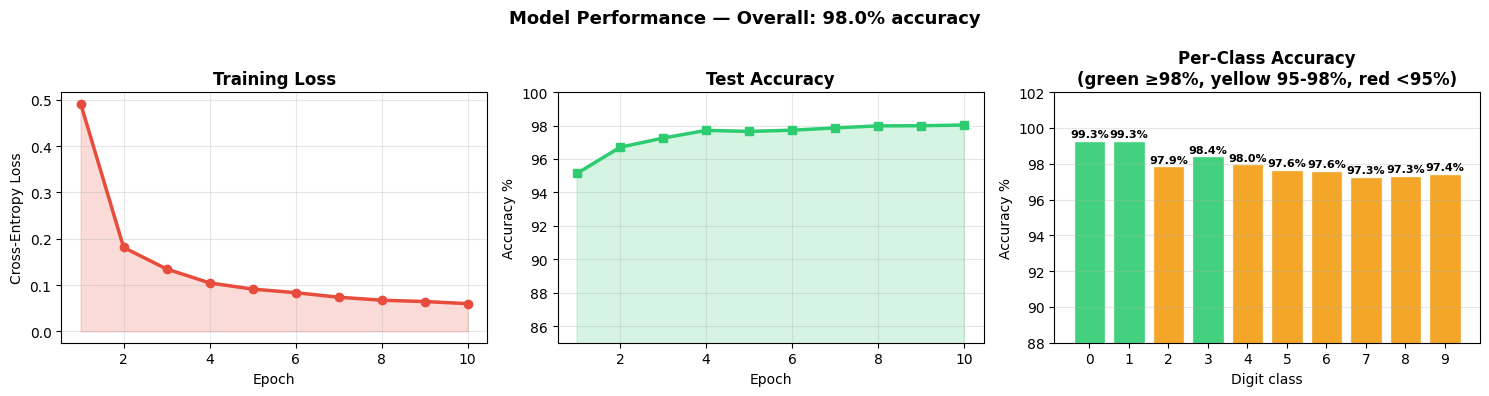

🔍 Most confused digit pairs:
   7 → predicted as 2: 10 times
   4 → predicted as 9: 9 times
   5 → predicted as 3: 8 times


In [7]:
from sklearn.metrics import confusion_matrix

# Collect predictions
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_ld:
        preds = model(x.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)
per_class = np.diag(cm) / cm.sum(axis=1) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(range(1,EPOCHS+1), train_losses, '#E74C3C', lw=2.5, marker='o', ms=6)
axes[0].fill_between(range(1,EPOCHS+1), train_losses, alpha=0.2, color='#E74C3C')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(range(1,EPOCHS+1), test_accs, '#2ECC71', lw=2.5, marker='s', ms=6)
axes[1].fill_between(range(1,EPOCHS+1), test_accs, alpha=0.2, color='#2ECC71')
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy %')
axes[1].set_ylim(85, 100); axes[1].grid(True, alpha=0.3)

# Per-class accuracy
colors = ['#2ECC71' if a>=98 else '#F39C12' if a>=95 else '#E74C3C' for a in per_class]
bars = axes[2].bar(range(10), per_class, color=colors, alpha=0.9, edgecolor='white')
for bar, acc in zip(bars, per_class):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{acc:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[2].set_xticks(range(10))
axes[2].set_xlabel('Digit class'); axes[2].set_ylabel('Accuracy %')
axes[2].set_title('Per-Class Accuracy\n(green ≥98%, yellow 95-98%, red <95%)', fontweight='bold')
axes[2].set_ylim(88, 102); axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle(f'Model Performance — Overall: {np.mean(per_class):.1f}% accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Most confused pairs
cm_nd = cm.copy(); np.fill_diagonal(cm_nd, 0)
print('🔍 Most confused digit pairs:')
for _ in range(3):
    i,j = np.unravel_index(cm_nd.argmax(), cm_nd.shape)
    print(f'   {i} → predicted as {j}: {cm_nd[i,j]} times')
    cm_nd[i,j]=0

---
## 🔍 Step 7: What Does Layer 1 Actually Learn?

Each of the 128 neurons in the first hidden layer has 784 weights — one per pixel.
If we reshape those weights back to 28×28, we can see exactly what **pattern** each neuron learned to look for.

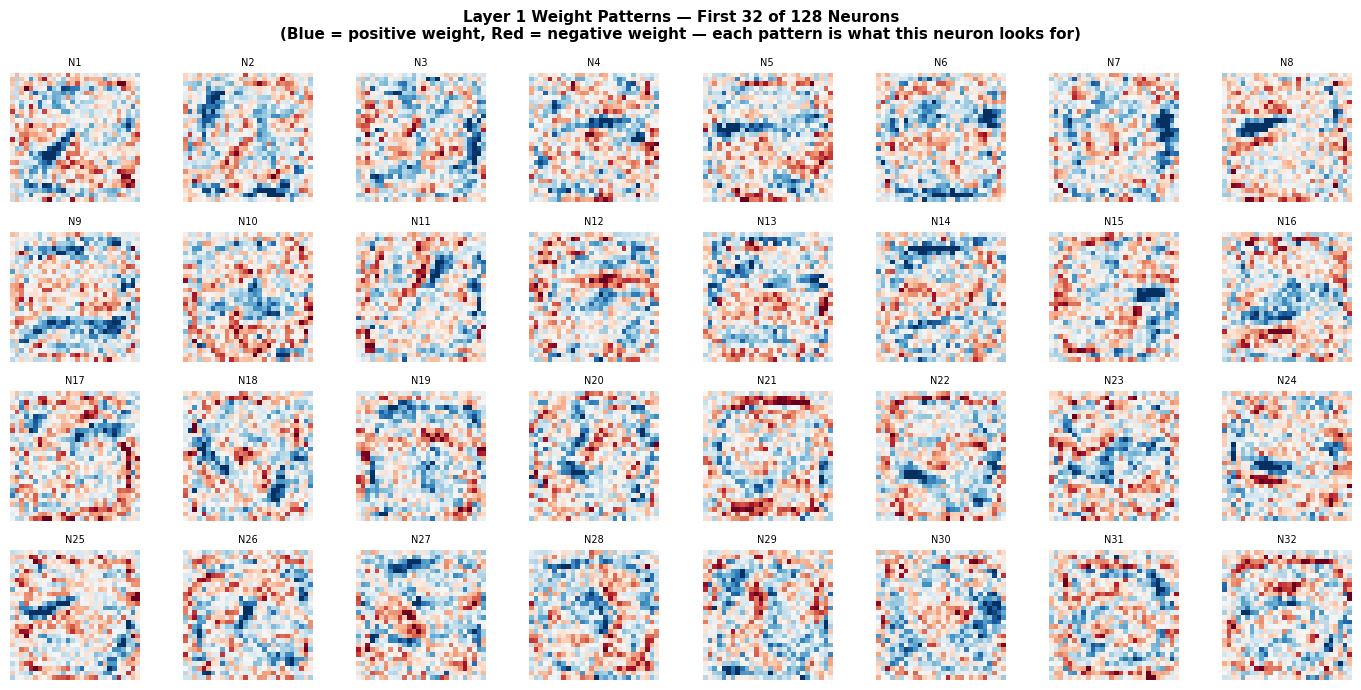

💡 Each 28×28 grid shows the weights of ONE neuron.
   Blue pixels = the neuron gets excited when this pixel is bright
   Red pixels  = the neuron gets suppressed when this pixel is bright
   You can see each neuron learned to detect different strokes and edges.


In [8]:
# Fused weights (same as what JS uses)
W1_fused = weights['W1']
W1_mat   = np.array(W1_fused).reshape(128, 784)

# Show first 32 neurons' weight patterns
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    w = W1_mat[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu_r', vmin=-w.std()*2.5, vmax=w.std()*2.5)
    ax.set_title(f'N{i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle('Layer 1 Weight Patterns — First 32 of 128 Neurons\n'
             '(Blue = positive weight, Red = negative weight — each pattern is what this neuron looks for)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Each 28×28 grid shows the weights of ONE neuron.')
print('   Blue pixels = the neuron gets excited when this pixel is bright')
print('   Red pixels  = the neuron gets suppressed when this pixel is bright')
print('   You can see each neuron learned to detect different strokes and edges.')

---
## 🎬 Step 8: Re-run the Visualizer
Run this cell any time to get a fresh interactive canvas.

In [9]:
# Re-display the full interactive visualizer
# (Run this cell any time after training to get a fresh canvas)
display(HTML(build_visualizer(weights)))

print('\n🖊️  Drawing tips for best results:')
print('   • Draw large, centered in the canvas')
print('   • Single clean strokes work better than shading')
print('   • The model was trained on thin handwritten digits')
print('   • Watch the 3-phase animation: input → layer1 → layer2 → output')


🖊️  Drawing tips for best results:
   • Draw large, centered in the canvas
   • Single clean strokes work better than shading
   • The model was trained on thin handwritten digits
   • Watch the 3-phase animation: input → layer1 → layer2 → output


---
## 🏁 Summary

| Component | What it does |
|-----------|-------------|
| **MNIST** | 60,000 real handwritten digit images |
| **784 inputs** | Each pixel = one input neuron (28×28 = 784) |
| **Layer 1 (128)** | Learns edges and strokes — ReLU activation |
| **Layer 2 (64)** | Learns curves and loops — ReLU activation |
| **Output (10)** | One neuron per digit — highest wins |
| **BatchNorm** | Keeps activations stable during training |
| **Dropout** | Randomly drops neurons → prevents overfitting |
| **Weights export** | Python → JSON → JavaScript (same math) |
| **Visualizer** | Live neuron firing, connection glow, 3-phase animation |

---
*Built for SkillWisor — making AI visual and accessible for Indian builders 🇮🇳*